In [1]:
"""Bayesian Optimization Active Sampling with AP-SSP Planning."""
%load_ext autoreload
%autoreload 2
import jax
from jax import config
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import gpjax as gpx
import optax as ox
import sys
import os
from pathlib import Path


def add_project_root_to_path() -> Path:
    project_root = Path.cwd()
    for _ in range(10):
        if (project_root / "src").is_dir() and (project_root / "pixi.toml").exists():
            break
        parent = project_root.parent
        if parent == project_root:
            raise FileNotFoundError("Project root (directory with src/ and pixi.toml) not found.")
        project_root = parent
    root_str = str(project_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    return project_root

add_project_root_to_path()

from src.env.field.rff_gp_field import RFFGPField
from src.env.actor.grid_actor import GridActor
from src.env.arena.dynamic_sg_arena import DynamicSGArena
from src.env.arena.reward import StepCostReward
from src.env.utils.types import GridConfig, GridPosition
from src.env.rendering.multi_segment_renderer import MultiSegmentRenderer
from src.agents.ap_ssp_agent import APSSPAgent, APSSPAgentConfig

config.update("jax_enable_x64", True)

In [2]:
# 1. Setup True Field and Arena
# =============================
grid_size = 50
subgrid_size = 20
margin = (grid_size - subgrid_size) // 2

sigma_true = 3.0
lengthscale_true = 2.5
nu_true = 2.5
noise_std_true = 0.2
seed = 42
boundary_mode = "terminal"

key = jr.PRNGKey(seed)
key, field_key = jr.split(key)

grid_config = GridConfig.create(n_x=grid_size, n_y=grid_size)
field = RFFGPField(
    config=grid_config,
    d_max=10,
    sigma=sigma_true,
    lengthscale=lengthscale_true,
    nu=nu_true,
    noise_std=noise_std_true,
)
field.reset(field_key)
true_u = field._precomputed_u.squeeze()

# Build Actor & Arena
actor = GridActor(noise_std=0.0)
vicinity_radius = 0.0
step_cost = 1.0

initial_pos = GridPosition(int(grid_size // 2), int(grid_size // 2))
reward_fn = StepCostReward(
    target_position=initial_pos,
    vicinity_radius=vicinity_radius,
    step_cost=step_cost,
)

arena = DynamicSGArena(
    field=field,
    actor=actor,
    config=grid_config,
    initial_position=initial_pos,
    target_position=initial_pos,
    vicinity_radius=vicinity_radius,
    boundary_mode=boundary_mode,
    vicinity_metric="euclidean",
    reward_fn=reward_fn,
)

key, reset_key = jr.split(key)
arena.reset(reset_key)

# Plan AP-SSP
print(f"Planning AP-SSP for all state-goal pairs ({grid_size}x{grid_size}) ...")
agent = APSSPAgent(APSSPAgentConfig(max_iters=200, tol=1e-3))
agent.plan(arena)
print("Planning complete!")

# Setup Full GP Test Grid for predictions
x_coords_full = jnp.arange(1, grid_size + 1)
y_coords_full = jnp.arange(1, grid_size + 1)
Xm_full, Ym_full = jnp.meshgrid(x_coords_full, y_coords_full, indexing="ij")
X_test_full = jnp.column_stack([Xm_full.ravel(), Ym_full.ravel()]).astype(jnp.float64)

# Setup Subgrid for Targeting and RMSE
x_coords_sub = jnp.arange(margin + 1, grid_size - margin + 1)
y_coords_sub = jnp.arange(margin + 1, grid_size - margin + 1)
Xm_sub, Ym_sub = jnp.meshgrid(x_coords_sub, y_coords_sub, indexing="ij")
X_test_sub = jnp.column_stack([Xm_sub.ravel(), Ym_sub.ravel()]).astype(jnp.float64)

true_u_subgrid = true_u[margin:-margin, margin:-margin]

var_init = 1.0
lengthscale_init = 1.0

W0313 15:34:31.433389 3012854 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Planning AP-SSP for all state-goal pairs (50x50) ...


AP-SSP Value Iteration: 100%|██████████| 200/200 [00:42<00:00,  4.67it/s, max_diff=31.8796] 

Planning complete!


In [3]:
# 2. General Evaluation and Acquisition Functions
# ===============================================
def evaluate_gp(X_tr, y_tr, optimize=False, alpha=None):
    dataset = gpx.Dataset(X=X_tr, y=y_tr)

    if optimize:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([0.5])
        )
        posterior = prior * likelihood

        def nmll(p, d):
            return -gpx.objectives.conjugate_mll(p, d)

        optim = ox.adam(learning_rate=0.05)
        opt_posterior, _ = gpx.fit(
            model=posterior,
            objective=nmll,
            train_data=dataset,
            optim=optim,
            num_iters=100,
        )
        latent_dist = opt_posterior.predict(X_test_full, train_data=dataset)
    else:
        kernel = gpx.kernels.Matern52(variance=var_init, lengthscale=lengthscale_init)
        prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
        likelihood = gpx.likelihoods.Gaussian(
            num_datapoints=dataset.n, obs_stddev=jnp.array([noise_std_true])
        )
        posterior = prior * likelihood
        latent_dist = posterior.predict(X_test_full, train_data=dataset)

    mu_full = latent_dist.mean.reshape(grid_size, grid_size)
    var_full = latent_dist.variance.reshape(grid_size, grid_size)

    # Calculate RMSE on subgrid
    mu_subgrid = mu_full[margin:-margin, margin:-margin]
    true_u_flat = true_u_subgrid.ravel()
    mu_flat = mu_subgrid.ravel()

    if alpha is not None:
        mask = jnp.abs(true_u_flat) > alpha
        if jnp.sum(mask) == 0:
            rmse_val = 0.0
        else:
            rmse_val = jnp.sqrt(jnp.mean((true_u_flat[mask] - mu_flat[mask]) ** 2))
    else:
        rmse_val = jnp.sqrt(jnp.mean((true_u_flat - mu_flat) ** 2))

    return mu_full, var_full, float(rmse_val)


def ei_acq(mu_flat, var_flat, y_train):
    f_best = jnp.max(y_train)
    sigma = jnp.sqrt(jnp.maximum(var_flat, 1e-9))
    z = (mu_flat - f_best) / sigma
    phi = jax.scipy.stats.norm.pdf(z)
    Phi = jax.scipy.stats.norm.cdf(z)
    ei = (mu_flat - f_best) * Phi + sigma * phi
    return jnp.where(sigma > 1e-6, ei, 0.0)

In [4]:
# 3. Trajectory Loop Function
# ===========================
def run_trajectory_loops(
    acq_type, max_total_samples=150, max_steps_per_loop=30, alpha=None, gif_path=None
):
    global key
    print(f"\n--- Running Strategy: {acq_type} ---")

    # Optional renderer for trajectory GIF
    renderer = None
    if gif_path is not None:
        renderer = MultiSegmentRenderer(
            config=grid_config,
            show_grid_points=True,
            width=900,
            height=900,
            field=field,
            show_field=True,
        )

    # Reset so each strategy / re-run starts at step 0 (no field re-sample)
    try:
        obs = arena.reset_counters_and_position(initial_pos)
    except AttributeError:
        # Arena was created before reset_counters_and_position existed; reset inline
        arena.set_position(initial_pos)
        arena.last_position = arena.position
        arena.step_count = 0
        arena._segment_step_count = 0
        arena._segment_cumulative_reward = 0.0
        arena._target_reached = False
        arena._segment_index = 0
        arena._global_step_count = 0
        arena._global_cumulative_reward = 0.0
        arena._last_action = None
        arena._last_reward = 0.0
        arena.last_displacement = arena._zero_displacement()
        obs = arena._get_observation()

    X_obs = []
    y_obs = []

    # Initial sample
    key, noise_key = jr.split(key)
    disp = field.sample_displacement(initial_pos, noise_key)
    X_obs.append([initial_pos.i, initial_pos.j])
    y_obs.append([disp.u])

    rmse_history = []
    loop_idx = 1

    while len(X_obs) < max_total_samples:
        X_tr = jnp.array(X_obs, dtype=jnp.float64)
        y_tr = jnp.array(y_obs, dtype=jnp.float64)

        mu, var, rmse = evaluate_gp(X_tr, y_tr, optimize=True, alpha=alpha)
        rmse_history.append((len(X_obs), rmse))
        print(
            f"Loop {loop_idx} | Samples: {len(X_obs)}/{max_total_samples} | RMSE: {rmse:.4f}"
        )

        # Extract subgrid predictions for targeting
        mu_subgrid = mu[margin:-margin, margin:-margin]
        var_subgrid = var[margin:-margin, margin:-margin]

        mu_flat = mu_subgrid.ravel()
        var_flat = var_subgrid.ravel()

        current_pos = arena.position

        # Mask points already in vicinity to avoid "vicinity trap"
        dist_to_current = jnp.sqrt(
            (X_test_sub[:, 0] - current_pos.i) ** 2
            + (X_test_sub[:, 1] - current_pos.j) ** 2
        )
        valid_mask = dist_to_current > vicinity_radius

        if acq_type == "random":
            key, subkey = jr.split(key)
            valid_indices = jnp.where(valid_mask)[0]
            if len(valid_indices) == 0:
                print("  -> No valid targets left outside vicinity. Terminating early.")
                break
            idx_of_idx = jr.randint(subkey, (), 0, len(valid_indices))
            best_idx = int(valid_indices[idx_of_idx])
        elif acq_type == "max_variance":
            acq = jnp.where(valid_mask, var_flat, -jnp.inf)
            best_idx = int(jnp.argmax(acq))
        elif acq_type == "ei":
            acq = ei_acq(mu_flat, var_flat, y_tr)
            acq = jnp.where(valid_mask, acq, -jnp.inf)
            best_idx = int(jnp.argmax(acq))
        elif acq_type == "cost_aware_ei":
            acq = ei_acq(mu_flat, var_flat, y_tr)
            costs_full = agent._cost_table[current_pos.i - 1, current_pos.j - 1, :, :]
            costs_subgrid = costs_full[margin:-margin, margin:-margin]
            costs = costs_subgrid.ravel()

            costs = jnp.maximum(costs, 1.0)
            acq_cost_aware = acq / costs
            acq_cost_aware = jnp.where(valid_mask, acq_cost_aware, -jnp.inf)
            best_idx = int(jnp.argmax(acq_cost_aware))
        else:
            raise ValueError(f"Unknown acq_type: {acq_type}")

        target_coords = X_test_sub[best_idx]
        target_pos = GridPosition(int(target_coords[0]), int(target_coords[1]))

        print(f"  -> Target: {target_pos} from {arena.position}")

        # Navigate to target
        arena.set_target(target_pos)
        agent.set_target(target_pos)
        obs = arena.soft_reset()

        if renderer is not None:
            renderer.new_segment()
            renderer.step(arena.get_state())

        action = agent.begin_episode(obs)
        steps_this_loop = 0
        crashed = False

        while steps_this_loop < max_steps_per_loop and len(X_obs) < max_total_samples:
            obs = arena.step(action)
            reward = arena.compute_reward()
            state = arena.get_state()

            if renderer is not None:
                renderer.step(state)

            # Record observation
            key, noise_key = jr.split(key)
            disp = field.sample_displacement(state.last_position, noise_key)
            X_obs.append([state.last_position.i, state.last_position.j])
            y_obs.append([disp.u])
            steps_this_loop += 1

            if state.target_reached:
                print(f"  -> Reached in {steps_this_loop} steps.")
                break
            if arena.is_terminal():
                print(f"  -> Out of bounds at {state.last_position}! Robot crashed.")
                arena.set_position(initial_pos)
                crashed = True
                break

            action = agent.step(reward, obs)

        if crashed:
            print("  -> Ending data collection for this strategy early due to crash.")
            break

        loop_idx += 1

    # Final eval
    X_tr = jnp.array(X_obs, dtype=jnp.float64)
    y_tr = jnp.array(y_obs, dtype=jnp.float64)
    mu, var, rmse = evaluate_gp(X_tr, y_tr, optimize=False, alpha=alpha)
    rmse_history.append((len(X_obs), rmse))

    if renderer is not None and gif_path is not None:
        os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)
        renderer.save_gif(gif_path, fps=5)
        print(f"  -> Trajectory GIF saved to {gif_path}")
        renderer.reset()

    print(f"Final | Samples: {len(X_obs)} | RMSE: {rmse:.4f}")
    return mu, var, X_tr, y_tr, rmse_history

In [5]:
# 4. Run Experiments
# ==================
max_total_samples = 100
max_steps_per_loop = 20
eval_alpha = 2.0  # Set to a threshold to estimate level sets, or None for whole subgrid

results = {}
strategies = ["random", "max_variance", "ei", "cost_aware_ei"]
labels = ["Random Target", "Max Variance", "Expected Improvement (EI)", "Cost-Aware EI"]

os.makedirs("plots/bo_active", exist_ok=True)
for strat in strategies:
    gif_path = f"plots/bo_active/trajectory_{strat}.gif"
    results[strat] = run_trajectory_loops(
        strat,
        max_total_samples=max_total_samples,
        max_steps_per_loop=max_steps_per_loop,
        alpha=eval_alpha,
        gif_path=gif_path,
    )


--- Running Strategy: random ---


  0%|          | 0/100 [00:00<?, ?it/s]

Loop 1 | Samples: 1/100 | RMSE: 3.4928
  -> Target: GridPosition(i=26, j=34, k=None) from GridPosition(i=25, j=25, k=None)
  -> Reached in 10 steps.


  0%|          | 0/100 [00:00<?, ?it/s]

Loop 2 | Samples: 11/100 | RMSE: 3.5660
  -> Target: GridPosition(i=16, j=31, k=None) from GridPosition(i=26, j=34, k=None)


...

Loop 17 | Samples: 62/100 | RMSE: 3.9698
  -> Target: GridPosition(i=16, j=24, k=None) from GridPosition(i=16, j=25, k=None)
  -> Reached in 11 steps.


  0%|          | 0/100 [00:00<?, ?it/s]

Loop 18 | Samples: 73/100 | RMSE: 4.0583
  -> Target: GridPosition(i=16, j=25, k=None) from GridPosition(i=16, j=24, k=None)
  -> Reached in 20 steps.


  0%|          | 0/100 [00:00<?, ?it/s]

Loop 19 | Samples: 93/100 | RMSE: 4.0121
  -> Target: GridPosition(i=17, j=24, k=None) from GridPosition(i=16, j=25, k=None)
GIF saved to: plots/bo_active/trajectory_cost_aware_ei.gif  (118 frames, 4180.2 KB)
  -> Trajectory GIF saved to plots/bo_active/trajectory_cost_aware_ei.gif
Final | Samples: 100 | RMSE: 3.7816



Generating plots...
Saved posteriors plot to plots/bo_active/bo_posteriors.png


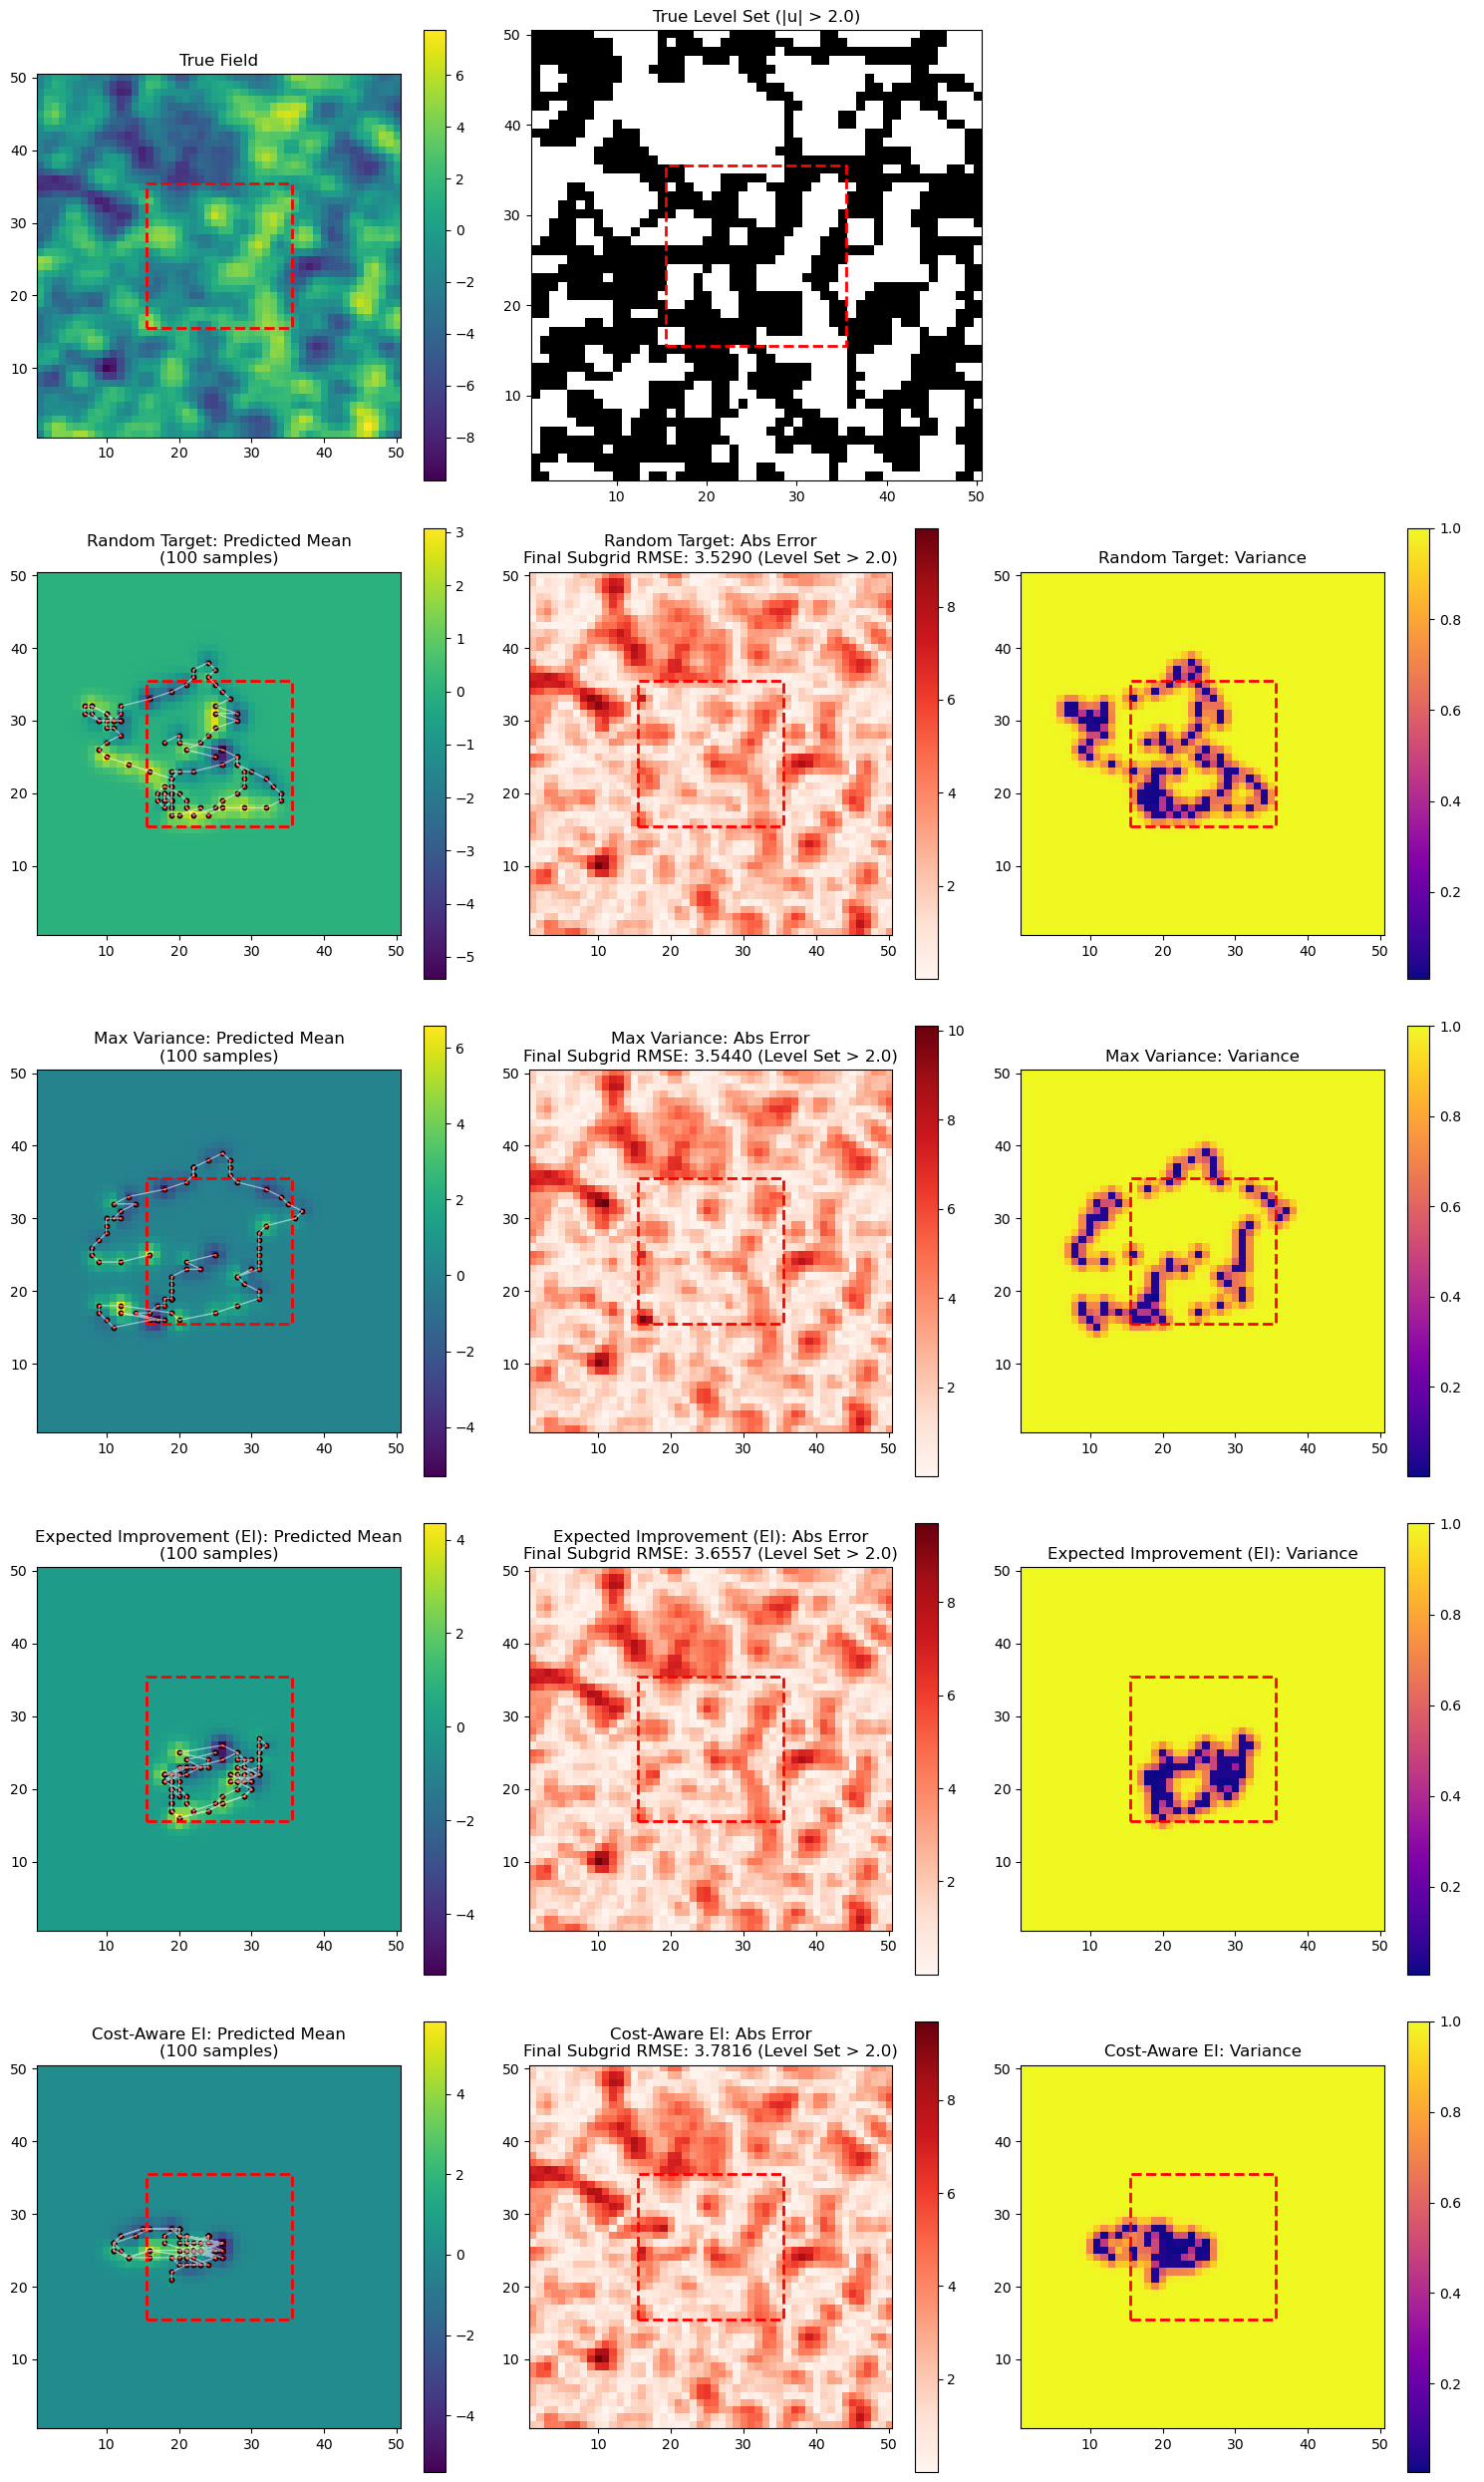

Saved RMSE scaling plot to plots/bo_active/bo_rmse_scaling.png


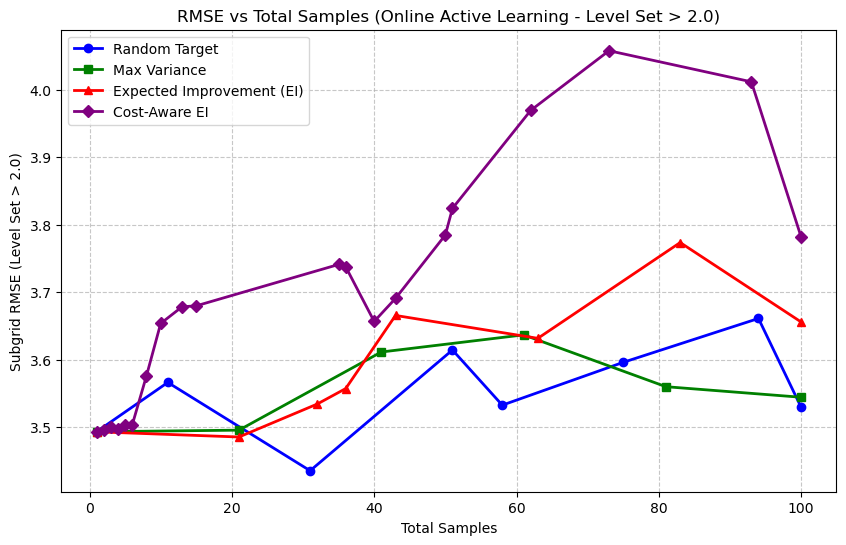

In [6]:
# 5. Plotting
# ===========
print("\nGenerating plots...")
os.makedirs("plots/bo_active", exist_ok=True)

fig, axes = plt.subplots(5, 3, figsize=(15, 25))

# Row 0: True Field
im0 = axes[0, 0].imshow(
    true_u.T,
    origin="lower",
    cmap="viridis",
    extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
)
axes[0, 0].set_title("True Field")
# Draw Subgrid boundary
rect = patches.Rectangle(
    (margin + 0.5, margin + 0.5),
    subgrid_size,
    subgrid_size,
    linewidth=2,
    edgecolor="r",
    facecolor="none",
    linestyle="--",
)
axes[0, 0].add_patch(rect)

plt.colorbar(im0, ax=axes[0, 0])

# True Field Level Set Mask (if alpha provided)
if eval_alpha is not None:
    mask_plot = (jnp.abs(true_u) > eval_alpha).astype(float)
    im0_mask = axes[0, 1].imshow(
        mask_plot.T,
        origin="lower",
        cmap="gray",
        extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
    )
    axes[0, 1].set_title(f"True Level Set (|u| > {eval_alpha})")
    rect_mask = patches.Rectangle(
        (margin + 0.5, margin + 0.5),
        subgrid_size,
        subgrid_size,
        linewidth=2,
        edgecolor="r",
        facecolor="none",
        linestyle="--",
    )
    axes[0, 1].add_patch(rect_mask)
else:
    axes[0, 1].axis("off")

axes[0, 2].axis("off")

for i, strat in enumerate(strategies):
    r = i + 1
    mu, var, X_tr, y_tr, rmse_hist = results[strat]

    # Col 0: Mean + Samples
    im_m = axes[r, 0].imshow(
        mu.T,
        origin="lower",
        cmap="viridis",
        extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
    )
    axes[r, 0].plot(X_tr[:, 0], X_tr[:, 1], color="white", alpha=0.5, linewidth=1)
    axes[r, 0].scatter(X_tr[:, 0], X_tr[:, 1], c="red", s=10, edgecolors="k")
    axes[r, 0].set_title(f"{labels[i]}: Predicted Mean\n({len(X_tr)} samples)")
    rect_m = patches.Rectangle(
        (margin + 0.5, margin + 0.5),
        subgrid_size,
        subgrid_size,
        linewidth=2,
        edgecolor="r",
        facecolor="none",
        linestyle="--",
    )
    axes[r, 0].add_patch(rect_m)
    plt.colorbar(im_m, ax=axes[r, 0])

    # Col 1: Error
    err = jnp.abs(true_u - mu)
    im_e = axes[r, 1].imshow(
        err.T,
        origin="lower",
        cmap="Reds",
        extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
    )
    title_rmse = f"Final Subgrid RMSE: {rmse_hist[-1][1]:.4f}"
    if eval_alpha is not None:
        title_rmse += f" (Level Set > {eval_alpha})"
    axes[r, 1].set_title(f"{labels[i]}: Abs Error\n{title_rmse}")
    rect_e = patches.Rectangle(
        (margin + 0.5, margin + 0.5),
        subgrid_size,
        subgrid_size,
        linewidth=2,
        edgecolor="r",
        facecolor="none",
        linestyle="--",
    )
    axes[r, 1].add_patch(rect_e)
    plt.colorbar(im_e, ax=axes[r, 1])

    # Col 2: Variance
    im_v = axes[r, 2].imshow(
        var.T,
        origin="lower",
        cmap="plasma",
        extent=[0.5, grid_size + 0.5, 0.5, grid_size + 0.5],
    )
    axes[r, 2].set_title(f"{labels[i]}: Variance")
    rect_v = patches.Rectangle(
        (margin + 0.5, margin + 0.5),
        subgrid_size,
        subgrid_size,
        linewidth=2,
        edgecolor="r",
        facecolor="none",
        linestyle="--",
    )
    axes[r, 2].add_patch(rect_v)
    plt.colorbar(im_v, ax=axes[r, 2])

plt.tight_layout()
posteriors_path = "plots/bo_active/bo_posteriors.png"
plt.savefig(posteriors_path)
print(f"Saved posteriors plot to {posteriors_path}")
plt.show()

# Figure: RMSE Scaling
plt.figure(figsize=(10, 6))
colors = ["b", "g", "r", "purple"]
markers = ["o", "s", "^", "D"]

for i, strat in enumerate(strategies):
    rmse_hist = results[strat][4]
    loops_x = [x[0] for x in rmse_hist]
    loops_y = [x[1] for x in rmse_hist]
    plt.plot(
        loops_x,
        loops_y,
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        linewidth=2,
    )

plt.xlabel("Total Samples")
if eval_alpha is not None:
    plt.ylabel(f"Subgrid RMSE (Level Set > {eval_alpha})")
    plt.title(
        f"RMSE vs Total Samples (Online Active Learning - Level Set > {eval_alpha})"
    )
else:
    plt.ylabel("Subgrid RMSE")
    plt.title("RMSE vs Total Samples (Online Active Learning)")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
rmse_path = "plots/bo_active/bo_rmse_scaling.png"
plt.savefig(rmse_path)
print(f"Saved RMSE scaling plot to {rmse_path}")
plt.show()